# TD4 Régression Linéaire & Logistique
# Ayman Chabbaki  G1
# Notebook implementing TD4 exercises: Gradient Descent, Linear and Logistic Regression


In [2]:
# Section 1 — Environment setup and data loading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# sklearn imports
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,
                             classification_report, roc_auc_score, roc_curve,
                             precision_recall_curve, confusion_matrix)

# Try to set seaborn style, fallback if not available
try:
    sns.set_style('darkgrid')
except Exception:
    pass

# Load California housing
housing = fetch_california_housing(as_frame=True)
df_h = housing.frame
print('California Housing shape:', df_h.shape)

# Load BankChurners
data_path = Path('BankChurners.csv')
if not data_path.exists():
    print('Warning: BankChurners.csv not found in workspace root.')
raw = pd.read_csv(data_path)
# Use same structure as TD2: drop last two metadata cols if present
if raw.shape[1] > 20:
    df_b = raw[raw.columns[:-2]].copy()
else:
    df_b = raw.copy()
# create churn target
if 'Attrition_Flag' in df_b.columns:
    df_b['churn'] = (df_b['Attrition_Flag']=='Attrited Customer').astype(int)
else:
    # fallback: if churn already exists
    if 'churn' not in df_b.columns:
        raise ValueError('Cannot find Attrition_Flag or churn column in BankChurners.csv')

print('BankChurners shape:', df_b.shape)


California Housing shape: (20640, 9)
BankChurners shape: (10127, 20)


GD theta: [4.1052011  2.96096451]
Analytic theta: [4.10520115 2.96096447]


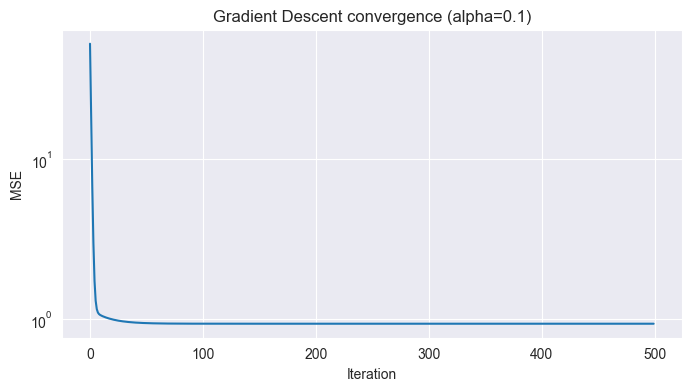

In [3]:
## Section 2 — Gradient Descent (NumPy) from scratch
# Synthetic dataset
np.random.seed(42)
X_syn = 2 * np.random.rand(200, 1)
y_syn = 4 + 3 * X_syn.ravel() + np.random.randn(200)

def gradient_descent(X, y, alpha=0.01, n_iter=1000):
    m = len(y)
    X_b = np.c_[np.ones((m, 1)), X]
    theta = np.zeros(X_b.shape[1])
    mse_history = []
    for iteration in range(n_iter):
        y_hat = X_b @ theta
        errors = y_hat - y
        gradient = (2/m) * X_b.T @ errors
        theta = theta - alpha * gradient
        mse_history.append(np.mean(errors**2))
    return theta, mse_history

# Train and compare with analytic solution
theta_gd, history = gradient_descent(X_syn, y_syn, alpha=0.1, n_iter=500)
X_b = np.c_[np.ones((X_syn.shape[0],1)), X_syn]
theta_analytic = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y_syn
print('GD theta:', theta_gd)
print('Analytic theta:', theta_analytic)

# Plot convergence
plt.figure(figsize=(8,4))
plt.plot(history)
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('Gradient Descent convergence (alpha=0.1)')
plt.show()


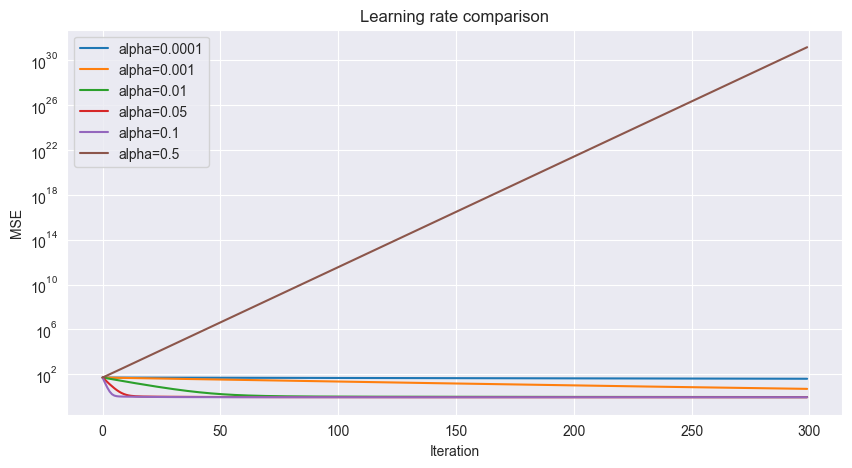

    alpha     final_mse        theta0        theta1
0  0.0001  4.104913e+01  3.933412e-01  4.376208e-01
1  0.0010  5.169058e+00  2.402806e+00  2.612889e+00
2  0.0100  9.654088e-01  3.773536e+00  3.247636e+00
3  0.0500  9.338381e-01  4.098861e+00  2.966445e+00
4  0.1000  9.338262e-01  4.105159e+00  2.961001e+00
5  0.5000  1.310019e+31 -1.820527e+15 -2.106156e+15


In [4]:
## Section 3 — Learning rate experimentation
alphas = [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5]
results = []
plt.figure(figsize=(10,5))
for alpha in alphas:
    theta, hist = gradient_descent(X_syn, y_syn, alpha=alpha, n_iter=300)
    results.append({'alpha': alpha, 'final_mse': hist[-1], 'theta0': theta[0], 'theta1': theta[1]})
    plt.plot(hist, label=f'alpha={alpha}')

plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('Learning rate comparison')
plt.legend()
plt.show()

import pandas as pd
print(pd.DataFrame(results))


Top correlations:
 MedInc        0.688
AveRooms      0.152
HouseAge      0.106
AveOccup     -0.024
Population   -0.025
Longitude    -0.046
AveBedrms    -0.047
Latitude     -0.144
Name: MedHouseVal, dtype: float64
Coef: 0.4193384939381274 Intercept: 0.44459729169078677
R2: 0.45885918903846656
RMSE: 0.8420901241414454
MAE: 0.629908653009376


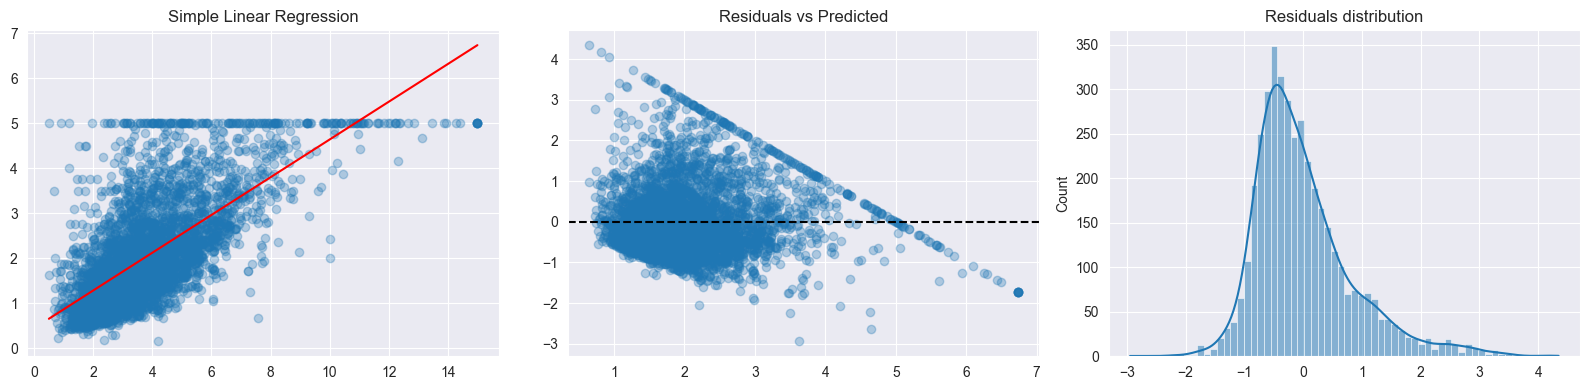

In [5]:
## Section 4 — Simple Linear Regression (California Housing)
# Correlation
corr = df_h.corr()['MedHouseVal'].drop('MedHouseVal').sort_values(ascending=False)
print('Top correlations:\n', corr.round(3))

# use MedInc as suggested
X_simple = df_h[['MedInc']].values
y_house = df_h['MedHouseVal'].values
X_tr, X_te, y_tr, y_te = train_test_split(X_simple, y_house, test_size=0.2, random_state=42)

lr_simple = LinearRegression()
lr_simple.fit(X_tr, y_tr)
y_pred_simple = lr_simple.predict(X_te)

print('Coef:', lr_simple.coef_[0], 'Intercept:', lr_simple.intercept_)
print('R2:', r2_score(y_te, y_pred_simple))
print('RMSE:', np.sqrt(mean_squared_error(y_te, y_pred_simple)))
print('MAE:', mean_absolute_error(y_te, y_pred_simple))

# plots
fig, axes = plt.subplots(1,3,figsize=(16,4))
# regression line
x_line = np.linspace(X_simple.min(), X_simple.max(), 100).reshape(-1,1)
axes[0].scatter(X_te, y_te, alpha=0.3)
axes[0].plot(x_line, lr_simple.predict(x_line), color='red')
axes[0].set_title('Simple Linear Regression')
# residuals
residuals = y_te - y_pred_simple
axes[1].scatter(y_pred_simple, residuals, alpha=0.3)
axes[1].axhline(0, color='k', ls='--')
axes[1].set_title('Residuals vs Predicted')
# residual dist
sns.histplot(residuals, kde=True, ax=axes[2])
axes[2].set_title('Residuals distribution')
plt.tight_layout(); plt.show()


R2: 0.575787706032451
RMSE: 0.7455813830127763

Top coefficients (standardized approx):
Latitude     -0.896929
Longitude    -0.869842
MedInc        0.854383
AveBedrms     0.339259
AveRooms     -0.294410
HouseAge      0.122546
AveOccup     -0.040829
Population   -0.002308
dtype: float64


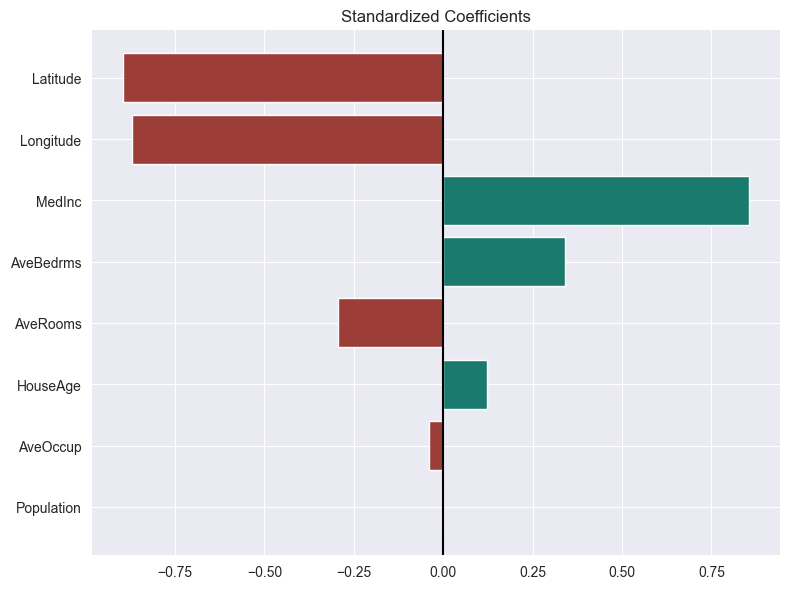

In [6]:
## Section 5 — Multiple Linear Regression (standardized coefficients)
feature_cols = [c for c in df_h.columns if c != 'MedHouseVal']
X_multi = df_h[feature_cols].values
y_house = df_h['MedHouseVal'].values
X_tr, X_te, y_tr, y_te = train_test_split(X_multi, y_house, test_size=0.2, random_state=42)

pipe_lr = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
pipe_lr.fit(X_tr, y_tr)
y_pred_multi = pipe_lr.predict(X_te)

print('R2:', r2_score(y_te, y_pred_multi))
print('RMSE:', np.sqrt(mean_squared_error(y_te, y_pred_multi)))

coefs = pd.Series(pipe_lr.named_steps['model'].coef_, index=feature_cols)
coefs_sorted = coefs.reindex(coefs.abs().sort_values(ascending=False).index)
print('\nTop coefficients (standardized approx):')
print(coefs_sorted.head(10))

# barplot
fig, ax = plt.subplots(figsize=(8,6))
colors = ['#1A7A6E' if v>0 else '#9C3D38' for v in coefs_sorted.values]
ax.barh(coefs_sorted.index[::-1], coefs_sorted.values[::-1], color=colors[::-1])
ax.axvline(0, color='k')
ax.set_title('Standardized Coefficients')
plt.tight_layout(); plt.show()


In [8]:
## Section 6 — BankChurners preprocessing and Logistic Regression baseline
# Defensive preprocessing: handle missing expected columns gracefully
df_enc = df_b.copy()

# Basic mappings (only map if columns exist)
if 'Gender' in df_enc.columns:
    df_enc['Gender'] = df_enc['Gender'].map({'M':1,'F':0})

mar_map = {'Single':0,'Married':1,'Divorced':2,'Unknown':-1}
if 'Marital_Status' in df_enc.columns:
    df_enc['Marital_Status'] = df_enc['Marital_Status'].map(mar_map)

edu_order = ['Unknown','Uneducated','High School','College','Graduate','Post-Graduate','Doctorate']
inc_order = ['Unknown','Less than $40K','$40K - $60K','$60K - $80K','$80K - $120K','$120K +']
if 'Education_Level' in df_enc.columns:
    df_enc['Education_Level'] = df_enc['Education_Level'].map({v:i for i,v in enumerate(edu_order)})
if 'Income_Category' in df_enc.columns:
    df_enc['Income_Category'] = df_enc['Income_Category'].map({v:i for i,v in enumerate(inc_order)})

# OHE for Card_Category if present
if 'Card_Category' in df_enc.columns:
    df_enc = pd.get_dummies(df_enc, columns=['Card_Category'], prefix='card', drop_first=True, dtype=int)

# Expected numeric columns (from TD instructions)
expected_num_cols = ['Customer_Age','Credit_Limit','Months_on_book','Total_Relationship_Count',
            'Months_Inactive_12_mon','Contacts_Count_12_mon','Total_Revolving_Bal',
            'Avg_Open_To_Buy','Total_Trans_Amt','Total_Trans_Ct','Avg_Utilization_Ratio',
            'Total_Amt_Chng_Q4_Q1','Total_Ct_Chng_Q4_Q1']
# Keep only those present in the dataframe
num_cols = [c for c in expected_num_cols if c in df_enc.columns]
missing_num = [c for c in expected_num_cols if c not in num_cols]
if missing_num:
    print('Warning: some expected numeric columns are missing and will be skipped:', missing_num)

# Define categorical columns as remaining columns except target/metadata
exclude = set(num_cols + ['Attrition_Flag','churn'])
cat_cols = [c for c in df_enc.columns if c not in exclude]

print(f'Using {len(num_cols)} numeric cols and {len(cat_cols)} other cols (total features = {len(num_cols)+len(cat_cols)})')

# Build feature matrix and target
X = df_enc[num_cols + cat_cols].fillna(0)
y = df_enc['churn']

# Train/test split with stratification
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Pipeline: scaling + logistic regression
pipe_log = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000, random_state=42))])
pipe_log.fit(X_tr, y_tr)

y_pred_log = pipe_log.predict(X_te)
y_prob_log = pipe_log.predict_proba(X_te)[:,1]

print('Logistic baseline classification report:')
print(classification_report(y_te, y_pred_log))
print('AUC-ROC:', roc_auc_score(y_te, y_prob_log))


Using 11 numeric cols and 9 other cols (total features = 20)
Logistic baseline classification report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      1701
           1       0.78      0.52      0.63       325

    accuracy                           0.90      2026
   macro avg       0.85      0.75      0.78      2026
weighted avg       0.89      0.90      0.89      2026

AUC-ROC: 0.9054384298828743


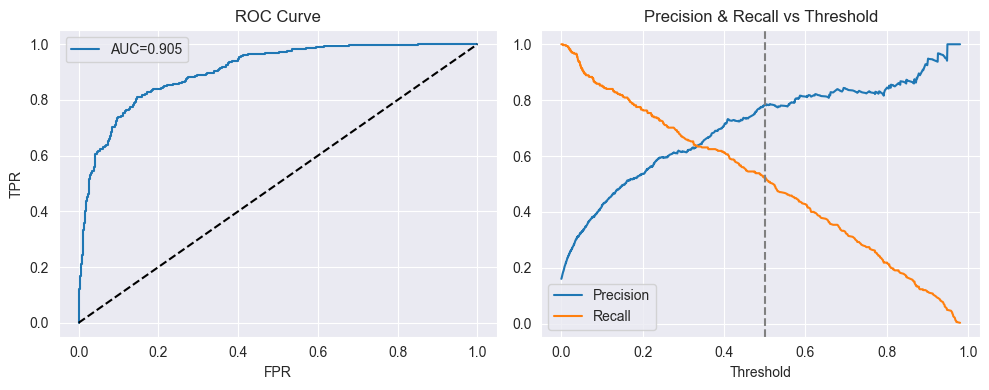

Youden optimal threshold: 0.16238565481790884
              precision    recall  f1-score   support

           0       0.96      0.85      0.90      1701
           1       0.51      0.81      0.63       325

    accuracy                           0.85      2026
   macro avg       0.74      0.83      0.77      2026
weighted avg       0.89      0.85      0.86      2026



In [9]:
## Section 7 — ROC curve and decision threshold tuning
fpr, tpr, thresh = roc_curve(y_te, y_prob_log)
auc = roc_auc_score(y_te, y_prob_log)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f'AUC={auc:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve')
plt.legend()

# Precision-Recall vs thresholds
precision, recall, pr_thresh = precision_recall_curve(y_te, y_prob_log)
plt.subplot(1,2,2)
# pr_thresh is length-1 shorter than precision/recall, align accordingly
plt.plot(pr_thresh, precision[:-1], label='Precision')
plt.plot(pr_thresh, recall[:-1], label='Recall')
plt.axvline(0.5, color='gray', ls='--')
plt.xlabel('Threshold')
plt.title('Precision & Recall vs Threshold')
plt.legend()
plt.tight_layout(); plt.show()

# Youden index
youden_idx = np.argmax(tpr - fpr)
opt_thresh = thresh[youden_idx]
print('Youden optimal threshold:', opt_thresh)

# Evaluate at optimal threshold
y_pred_opt = (y_prob_log >= opt_thresh).astype(int)
print(classification_report(y_te, y_pred_opt))


                          Coefficient  Odds_Ratio
Total_Trans_Ct                -2.7331      0.0650
Total_Trans_Amt                1.4810      4.3972
Total_Revolving_Bal           -0.8145      0.4429
Total_Relationship_Count      -0.7426      0.4759
Contacts_Count_12_mon          0.5955      1.8140
Months_Inactive_12_mon         0.5179      1.6785
Gender                        -0.4867      0.6147
Total_Amt_Chng_Q4_Q1          -0.3328      0.7169
Dependent_count                0.2149      1.2397
Marital_Status                -0.2083      0.8120
Income_Category                0.1976      1.2185
CLIENTNUM                     -0.1444      0.8655
card_Gold                      0.1092      1.1154
Credit_Limit                  -0.0748      0.9279
card_Silver                    0.0599      1.0617


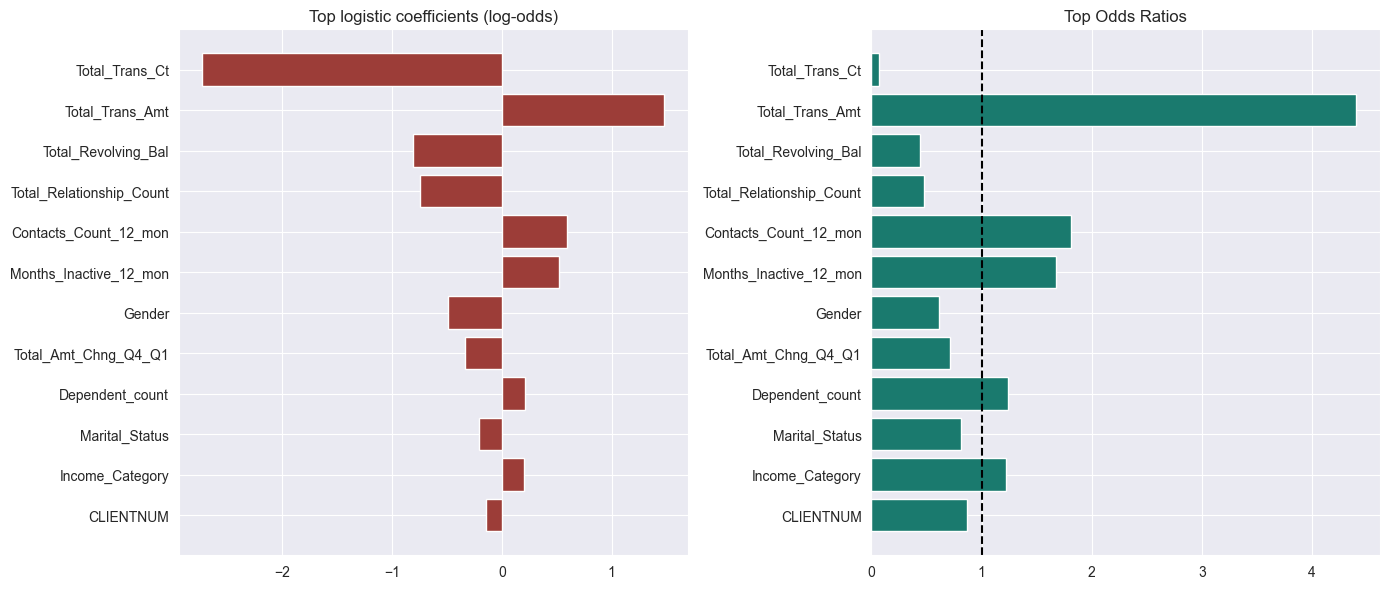

In [10]:
## Section 8 — Logistic coefficients and Odds Ratios
coefs_log = pd.Series(pipe_log.named_steps['model'].coef_[0], index=X_tr.columns)
coefs_log = coefs_log.sort_values(key=abs, ascending=False)
odds_ratios = np.exp(coefs_log)

coef_df = pd.DataFrame({'Coefficient': coefs_log.round(4), 'Odds_Ratio': odds_ratios.round(4)})
print(coef_df.head(15))

# plots
fig, axes = plt.subplots(1,2,figsize=(14,6))
top_n = 12
axes[0].barh(coefs_log.head(top_n).index[::-1], coefs_log.head(top_n).values[::-1], color='#9C3D38')
axes[0].set_title('Top logistic coefficients (log-odds)')
axes[1].barh(odds_ratios.head(top_n).index[::-1], odds_ratios.head(top_n).values[::-1], color='#1A7A6E')
axes[1].axvline(1, color='k', ls='--')
axes[1].set_title('Top Odds Ratios')
plt.tight_layout(); plt.show()


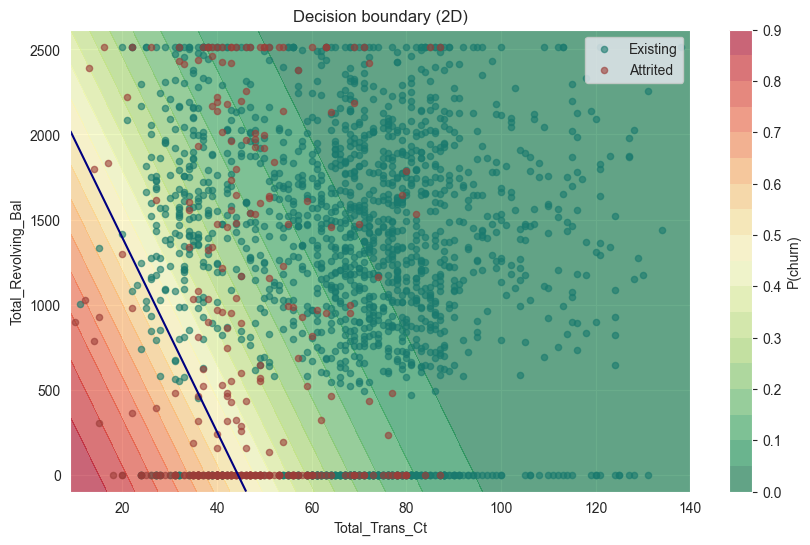

In [11]:
## Section 9 — 2D Decision Boundary Visualization
feat1 = 'Total_Trans_Ct'
feat2 = 'Total_Revolving_Bal'
if feat1 in df_enc.columns and feat2 in df_enc.columns:
    X_2d = df_enc[[feat1, feat2]].values
    y_2d = df_enc['churn'].values
    X_2d_tr, X_2d_te, y_2d_tr, y_2d_te = train_test_split(X_2d, y_2d, test_size=0.2, random_state=42, stratify=y_2d)
    pipe_2d = Pipeline([('sc', StandardScaler()), ('lr', LogisticRegression(max_iter=1000, C=1.0))])
    pipe_2d.fit(X_2d_tr, y_2d_tr)
    xx1_min, xx1_max = X_2d[:,0].min()-1, X_2d[:,0].max()+1
    xx2_min, xx2_max = X_2d[:,1].min()-100, X_2d[:,1].max()+100
    xx1, xx2 = np.meshgrid(np.linspace(xx1_min, xx1_max, 200), np.linspace(xx2_min, xx2_max, 200))
    Z = pipe_2d.predict_proba(np.c_[xx1.ravel(), xx2.ravel()])[:,1].reshape(xx1.shape)
    plt.figure(figsize=(10,6))
    plt.contourf(xx1, xx2, Z, levels=20, cmap='RdYlGn_r', alpha=0.6)
    plt.colorbar(label='P(churn)')
    plt.contour(xx1, xx2, Z, levels=[0.5], colors='navy')
    for cls, color, lab in [(0,'#1A7A6E','Existing'), (1,'#9C3D38','Attrited')]:
        mask = y_2d_te==cls
        plt.scatter(X_2d_te[mask,0], X_2d_te[mask,1], c=color, label=lab, s=20, alpha=0.6)
    plt.xlabel(feat1); plt.ylabel(feat2); plt.legend(); plt.title('Decision boundary (2D)'); plt.show()
else:
    print('Selected features not found for 2D visualization.')


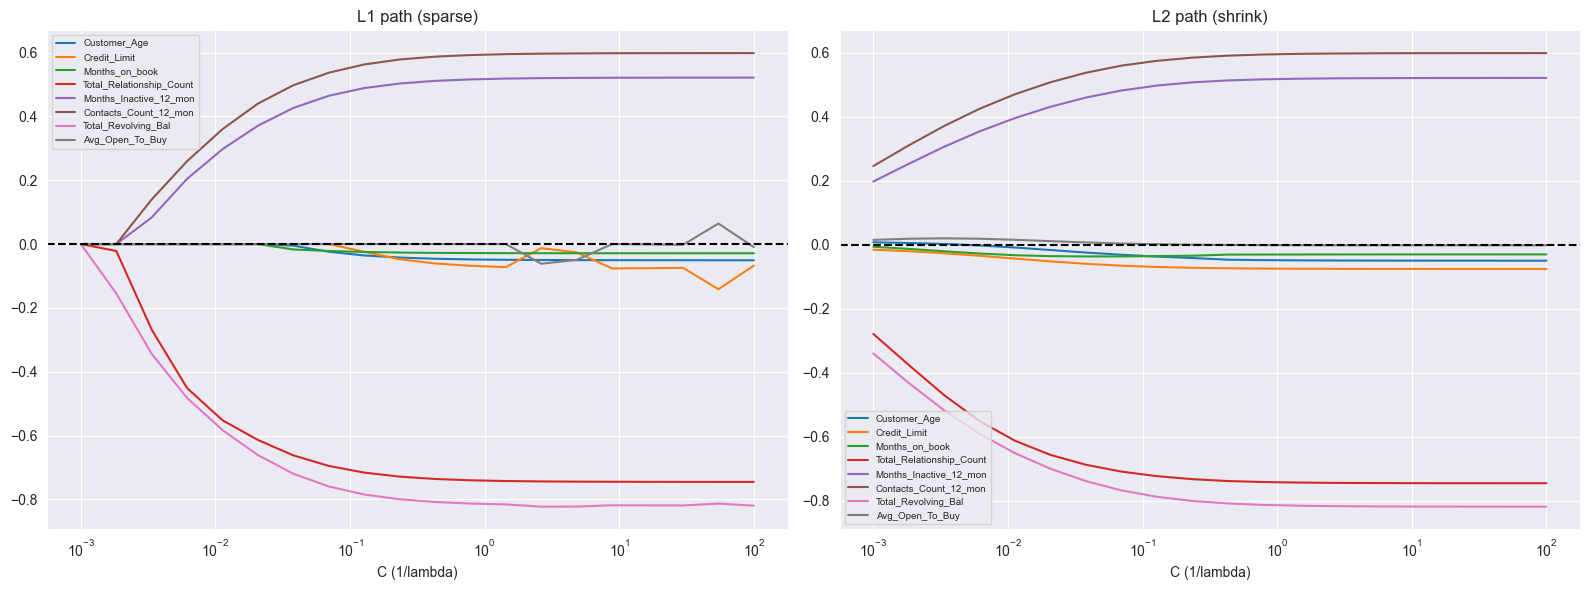

In [12]:
## Section 10 — L1 vs L2 Regularization Paths
C_values = np.logspace(-3, 2, 20)
# pick top features (or first 8) for plotting
plot_feats = list(X_tr.columns[:8])
coefs_l1 = {f: [] for f in plot_feats}
coefs_l2 = {f: [] for f in plot_feats}

scaler_reg = StandardScaler()
X_tr_sc = scaler_reg.fit_transform(X_tr)
for C in C_values:
    lr1 = LogisticRegression(C=C, penalty='l1', solver='liblinear', max_iter=1000)
    lr1.fit(X_tr_sc, y_tr)
    lr2 = LogisticRegression(C=C, penalty='l2', solver='lbfgs', max_iter=1000)
    lr2.fit(X_tr_sc, y_tr)
    for f in plot_feats:
        idx = list(X_tr.columns).index(f)
        coefs_l1[f].append(lr1.coef_[0][idx])
        coefs_l2[f].append(lr2.coef_[0][idx])

fig, axes = plt.subplots(1,2,figsize=(16,6))
for f in plot_feats:
    axes[0].plot(C_values, coefs_l1[f], label=f)
    axes[1].plot(C_values, coefs_l2[f], label=f)

for ax, title in zip(axes, ['L1 path (sparse)','L2 path (shrink)']):
    ax.set_xscale('log')
    ax.axhline(0, color='k', ls='--')
    ax.set_title(title)
    ax.set_xlabel('C (1/lambda)')
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()


Best C: {'model__C': 10}


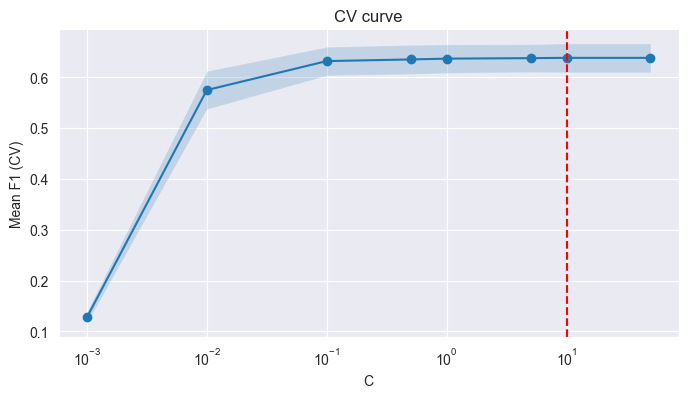

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      1701
           1       0.78      0.53      0.63       325

    accuracy                           0.90      2026
   macro avg       0.85      0.75      0.79      2026
weighted avg       0.89      0.90      0.89      2026



In [13]:
## Section 11 — Cross-validation for optimal C (GridSearchCV)
param_grid = {'model__C':[0.001,0.01,0.1,0.5,1,5,10,50]}
pipe_cv = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000))])

grid = GridSearchCV(pipe_cv, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_tr, y_tr)
print('Best C:', grid.best_params_)
cv_results = pd.DataFrame(grid.cv_results_)
plt.figure(figsize=(8,4))
plt.semilogx(param_grid['model__C'], cv_results['mean_test_score'], '-o')
plt.fill_between(param_grid['model__C'], cv_results['mean_test_score']-cv_results['std_test_score'], cv_results['mean_test_score']+cv_results['std_test_score'], alpha=0.2)
plt.axvline(grid.best_params_['model__C'], color='r', ls='--')
plt.xlabel('C'); plt.ylabel('Mean F1 (CV)'); plt.title('CV curve'); plt.show()

# Evaluate best model on test
y_best = grid.best_estimator_.predict(X_te)
print(classification_report(y_te, y_best))


In [14]:
## Section 12 — Polynomial Logistic Regression (bonus)
from sklearn.pipeline import make_pipeline
pipe_poly = make_pipeline(StandardScaler(), PolynomialFeatures(degree=2, include_bias=False), LogisticRegression(max_iter=1000))
# train on the 2D features if available
if 'pipe_2d' in globals():
    pipe_poly.fit(X_2d_tr, y_2d_tr)
    print('Linear 2D score:', pipe_2d.score(X_2d_te, y_2d_te))
    print('Poly deg2 2D score:', pipe_poly.score(X_2d_te, y_2d_te))
else:
    print('Skipping polynomial bonus: 2D features not available')


Linear 2D score: 0.8632773938795657
Poly deg2 2D score: 0.8805528134254689


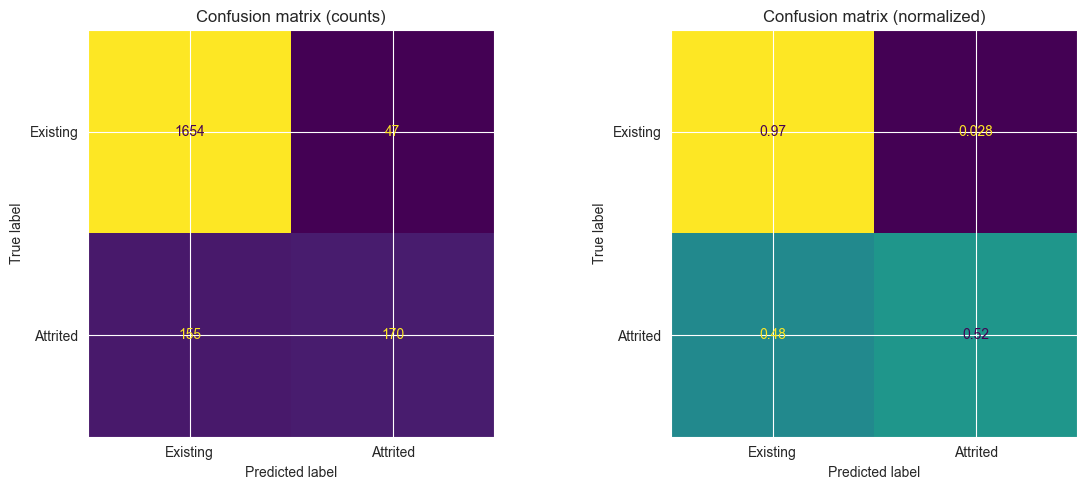


Average profile of false negatives:
Total_Trans_Ct           52.277
Total_Revolving_Bal    1068.832
dtype: float64


In [16]:
## Section 13 — Confusion matrix and false negative analysis (bonus)
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1,2,figsize=(12,5))
cm = confusion_matrix(y_te, y_pred_log)
disp = ConfusionMatrixDisplay(cm, display_labels=['Existing','Attrited'])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion matrix (counts)')
cmn = confusion_matrix(y_te, y_pred_log, normalize='true')
disp2 = ConfusionMatrixDisplay(cmn, display_labels=['Existing','Attrited'])
disp2.plot(ax=axes[1], colorbar=False)
axes[1].set_title('Confusion matrix (normalized)')
plt.tight_layout(); plt.show()

# False negatives profiling (defensive)
# Build boolean mask robustly using numpy arrays to avoid alignment issues
mask = (y_te.values == 1) & (y_pred_log == 0)
false_negatives = X_te.loc[mask] if hasattr(X_te, 'loc') else X_te[mask]

if isinstance(false_negatives, pd.DataFrame) and not false_negatives.empty:
    profile_cols = ['Total_Trans_Ct','Total_Revolving_Bal','Avg_Utilization_Ratio']
    available = [c for c in profile_cols if c in false_negatives.columns]
    if available:
        print('\nAverage profile of false negatives:')
        print(false_negatives[available].mean().round(3))
    else:
        print('Profile columns missing, available cols:', list(false_negatives.columns))
else:
    print('No false negatives found in test split or none of the profile columns are present')


## Conclusion (150 words)

This TD4 notebook compared linear and logistic regression techniques, implementing gradient descent from scratch to illustrate optimization behavior and numerically validating the analytical solution. For California Housing, multiple linear regression with standardized features improved R² compared to the single-feature model, demonstrating the value of combining informative predictors while requiring careful scaling. For the BankChurners churn prediction, logistic regression provided interpretable coefficients; converting them to odds ratios helps translate model outputs into actionable business insights. ROC and precision-recall analyses showed that default thresholds can be suboptimal on imbalanced data — tuning the threshold using Youden or business-oriented recall constraints substantially affects precision. L1 regularization induced sparsity useful for explainability, whereas L2 produced coefficient shrinkage without eliminating features. Cross-validation selected an appropriate regularization strength via F1, balancing recall and precision. Overall, model choice depends on the task: regression for continuous targets, logistic regression for binary outcomes, and regularization is essential for robust, interpretable models.
